In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
from os.path import exists
import numpy as np
import matplotlib.pyplot as plt
from corner import corner
from getdist import plots
import seaborn as sns
import scienceplots


import sys
sys.path.append("../")

from reconstruction_comparison import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"

In [2]:
def read_void_stats(profile):
    fname = f"/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/void_stats_{profile}.hdf5"

    with File(fname, 'r') as f:
        sizes, rLG, r_grid, phi_grid = [f[f"grid/{x}"][...]
                                        for x in ["sizes", "rLG", "r_grid", "phi_grid"]]
        r_bulk, enclosed_density, monopole, bulk_flow, enclosed_density_neg, monopole_neg, bulk_flow_neg = [
            f[f"void_stats/{x}"][...]
            for x in ["r", "enclosed_density", "monopole", "bulk_flow", "enclosed_density_negrLG", "monopole_negrLG", "bulk_flow_negrLG"]]

    return sizes, rLG, r_grid, phi_grid, r_bulk, enclosed_density, monopole, bulk_flow, enclosed_density_neg, monopole_neg, bulk_flow_neg


def read_void_stats_per_sample(fname):
    with File(fname.replace(".hdf5", "_stats.hdf5"), 'r') as f:
        r = f["void_stats/r"][...]
        Vext = f["void_stats/Vext"][...]
        Vmono = f["void_stats/monopole"][...]
        rho = f["void_stats/enclosed_density"][...]
        Vbulk_void = f["void_stats/bulk_flow"][...]
    
    Vtot = Vbulk_void + Vext[:, None, :]

    Vbulk_mag, Vmag_l, Vmag_b= cartesian_to_radec(
        Vtot[..., 0], Vtot[..., 1], Vtot[..., 2])
    Vmag_l, Vmag_b = csiborgtools.radec_to_galactic(Vmag_l, Vmag_b)

    Vbulk_void = np.linalg.norm(Vbulk_void, axis=-1)
    Vext = np.linalg.norm(Vext, axis=-1)

    return r, rho, Vmono, Vbulk_mag, Vbulk_void, Vext, Vmag_l, Vmag_b


In [3]:
import numpy as np
from h5py import File

from csiborgtools.flow import (load_void_size_variation, void_bulk_flow,
                               void_monopole)


def stats_per_sample(void_size, rLG, Vext, beta, void_data):
    is_negative_Roffset = rLG < 0

    i = np.argmin(np.abs(void_size - void_data["sizes"]))
    j = np.argmin(np.abs(np.abs(rLG) - void_data["rLG"]))

    rho = void_monopole(
        void_data["r"], void_data["rho"][i, j], void_data["ngrid"],
        void_data["r_grid"], void_data["phi_grid"], Vext, is_negative_Roffset,
        verbose=False)
    vmono = void_monopole(
        void_data["r"], void_data["vrad"][i, j], void_data["ngrid"],
        void_data["r_grid"], void_data["phi_grid"], Vext, is_negative_Roffset,
        verbose=False)
    vbulk = void_bulk_flow(
        void_data["r"], void_data["vx"][i, j], void_data["vx"][i, j],
        void_data["ngrid"], void_data["r_grid"], void_data["phi_grid"],
        Vext, is_negative_Roffset, verbose=False)

    return rho, beta * vmono, beta * vbulk


def main_sergij(profile):
    ngrid = 128

    if profile == "exp":
        rLG_sample = 36
        vvoid_sample = 688.56
    elif profile == "gauss":
        rLG_sample = 37
        vvoid_sample = 699
    elif profile == "mb":
        rLG_sample = -19
        vvoid_sample = 234
    else:
        raise ValueError(f"Profile `{profile}` not recognized.")

    # Load the data
    sizes, rLG, vx = load_void_size_variation(profile, "vx")
    sizes, rLG, vy = load_void_size_variation(profile, "vy")
    sizes, rLG, vrad = load_void_size_variation(profile, "vrad")
    sizes, rLG, rho = load_void_size_variation(profile, "density")

    # The void grids
    r_grid = np.arange(0, 401).astype(np.float32)
    phi_grid = np.arange(0, 181).astype(np.float32)

    # Compute the void statistics over 100 steps
    r = np.linspace(0, r_grid.max(), 100)

    void_data = {"sizes": sizes, "rLG": rLG,
                 "vx": vx, "vy": vy, "vrad": vrad, "rho": rho,
                 "r_grid": r_grid, "phi_grid": phi_grid, "r": r,
                 "ngrid": ngrid}
    Vext = vvoid_sample * np.asarray([-0.4035093, 0.01363162, -0.91487399])

    rho, Vmono, Vbulk = stats_per_sample(1., rLG_sample, Vext, 1., void_data)
    Vmag = np.linalg.norm(Vbulk + Vext[None, :], axis=1)
    return r, rho, Vmono, Vmag


def mainsizevar_sergij(profile):
    ngrid = 128

    if profile == "exp":
        rLG_sample = 25
        vvoid_sample = 430
        rvoid_sample = 0.06
    elif profile == "gauss":
        rLG_sample = 16
        vvoid_sample = 419
        rvoid_sample = 0.06
    elif profile == "mb":
        rLG_sample = 7
        vvoid_sample = 412
        rvoid_sample = 0.15
    else:
        raise ValueError(f"Profile `{profile}` not recognized.")

    # Load the data
    sizes, rLG, vx = load_void_size_variation(profile, "vx")
    sizes, rLG, vy = load_void_size_variation(profile, "vy")
    sizes, rLG, vrad = load_void_size_variation(profile, "vrad")
    sizes, rLG, rho = load_void_size_variation(profile, "density")

    # The void grids
    r_grid = np.arange(0, 401).astype(np.float32)
    phi_grid = np.arange(0, 181).astype(np.float32)

    # Compute the void statistics over 100 steps
    r = np.linspace(0, r_grid.max(), 100)

    void_data = {"sizes": sizes, "rLG": rLG,
                 "vx": vx, "vy": vy, "vrad": vrad, "rho": rho,
                 "r_grid": r_grid, "phi_grid": phi_grid, "r": r,
                 "ngrid": ngrid}
    Vext = vvoid_sample * np.asarray([-0.4035093, 0.01363162, -0.91487399])

    rho, Vmono, Vbulk = stats_per_sample(rvoid_sample, rLG_sample, Vext, 1., void_data)
    Vmag = np.linalg.norm(Vbulk + Vext[None, :], axis=1)
    return r, rho, Vmono, Vmag




### Quick checks

In [3]:
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers_stats.hdf5"
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5"
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoid_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.065_remove_CF4_outliers.hdf5"
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5"
fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5"



r, rho, Vmono, Vbulk_mag, Vbulk_void, Vext, Vmag_l, Vmag_b = read_void_stats_per_sample(fname)

/mnt/users/rstiskalek/csiborgtools/venv_csiborg/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


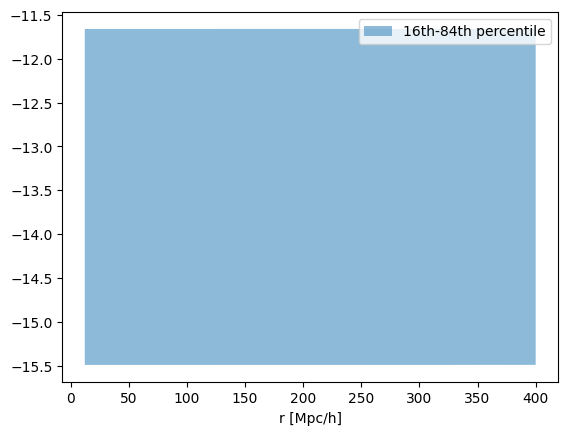

In [4]:
plt.figure()
ylow, ymed, yhigh = np.nanpercentile(Vmag_b, [16, 50, 84], axis=0)
plt.fill_between(r, ylow, yhigh, alpha=0.5, label="16th-84th percentile")
plt.xlabel("r [Mpc/h]")
# plt.xlim(0, 150)
# plt.ylabel("V_l [km/s]")
plt.legend()
plt.show()

In [7]:
samples["void_size"].shape

(1000,)

(4000,)
Read in samples are:
 ['Vmag', 'l', 'b', 'rLG']


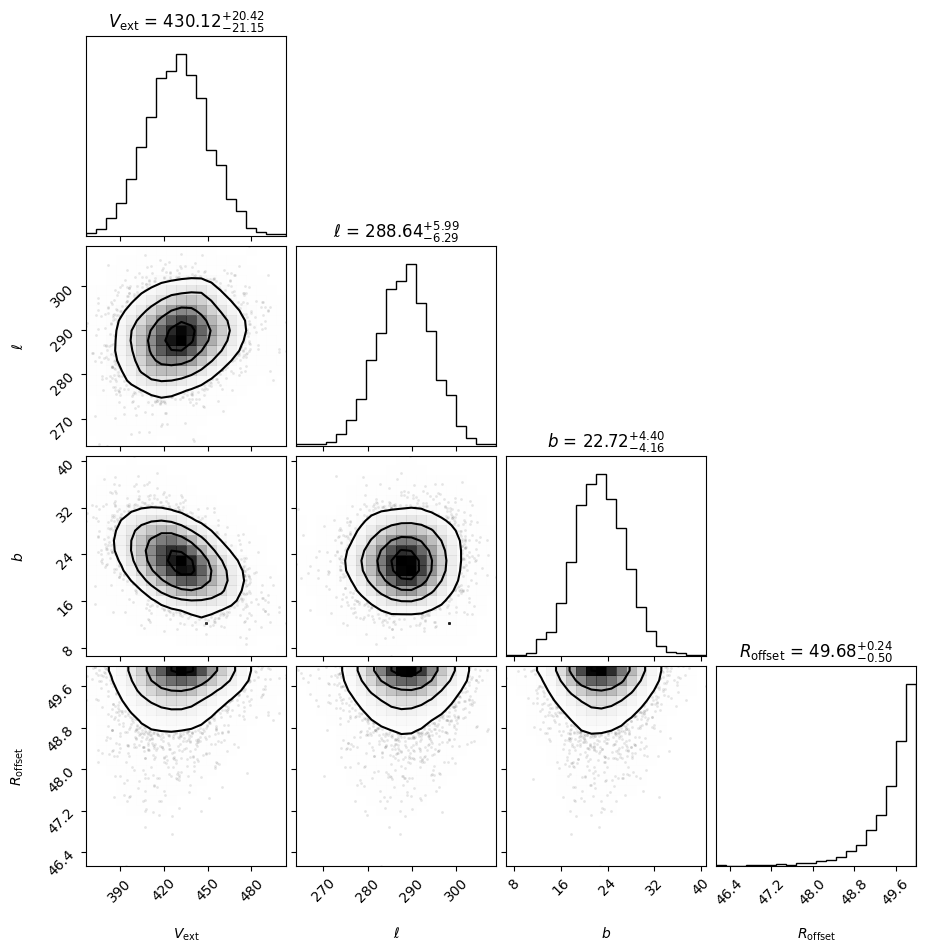

In [6]:
# Degeneracy example in mock:
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_gauss_IndranilVoidTFRMock_0_mike_zcmb_max_0.05_sample_beta_which_void_size_run_zoom.hdf5"

# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoid_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05.hdf5"


# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_no_field_300_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5"

# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoidSizeVar_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.065_sample_beta_which_void_size_run_coarse_remove_CF4_outliers.hdf5"
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5"
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_mb_CF4_TFR_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5"


fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoid_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5"


# samples = get_some_samples(fname, ["Vext", "rLG", ])
samples = get_some_samples(fname, ["Vext", "rLG", "void_size", "beta"])

print(samples["rLG"].shape)

print("Read in samples are:\n", list(samples.keys()))
data, labels, keys = samples_for_corner(samples)

fig = corner(data, labels=labels, show_titles=True,
             title_kwargs={"fontsize": 12}, smooth=1)

# fig.savefig("../../plots/exp_test.png", dpi=450)
fig.show()

In [9]:
fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoidSizeVar_gauss_CF4_TFR_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5"
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoid_gauss_CF4_TFR_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5"
samples = get_some_samples(fname, ["Vext", "rLG", "void_size", 'sigma_v', 'aTFR', 'bTFR', 'cTFR', 'beta'])

print("Read in samples are:\n", list(samples.keys()))
data, labels, keys = samples_for_corner(samples)

# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoid_gauss_CF4_TFR_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5"
# samples = get_some_samples(fname, ["Vext", "rLG", "void_size", 'sigma_v', 'aTFR', 'bTFR', 'cTFR'])
# data2, __, __ = samples_for_corner(samples)



fig = corner(data, labels=labels, show_titles=True,
             title_kwargs={"fontsize": 12}, smooth=1, hist_kwargs={"density": True},)
# corner(data2, fig=fig, labels=labels, show_titles=True,
#        title_kwargs={"fontsize": 12}, smooth=1,
    #    color='red', label_kwargs={"fontsize": 14}, hist_kwargs={"density": True})

# fig.savefig("../../plots/exp_test.png", dpi=450)
fig.savefig("void_test.png", dpi=450)
fig.show()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoidSizeVar_gauss_CF4_TFR_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

### Sergij's $\chi^2$ grid

In [11]:
kind = "MB"
# fpath = f"/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/ChiSq2D_{kind}profileresolution_3501x601.dat"  # noqa
fpath = f"/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/chi2grids_April2025/ChiSq2D_{kind}profile_voidsize15.dat"

print(f"Reading the chi2 grid from `{fpath}`.")
data = np.genfromtxt(fpath)

i, j = np.unravel_index(np.argmin(data), data.shape)

Roffset_range = np.arange(-150, 150 + 1)
Vext_range = np.arange(0, 3500 + 1)

print(f"Minimum chi2: {data[i, j]} at Roffset_index = {j}, Vext_index = {i}.")
print(f"Roffset = {Roffset_range[j]} Mpc, Vext = {Vext_range[i]} km/s.")

Reading the chi2 grid from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/chi2grids_April2025/ChiSq2D_MBprofile_voidsize15.dat`.
Minimum chi2: 11.011 at Roffset_index = 157, Vext_index = 412.
Roffset = 7 Mpc, Vext = 412 km/s.


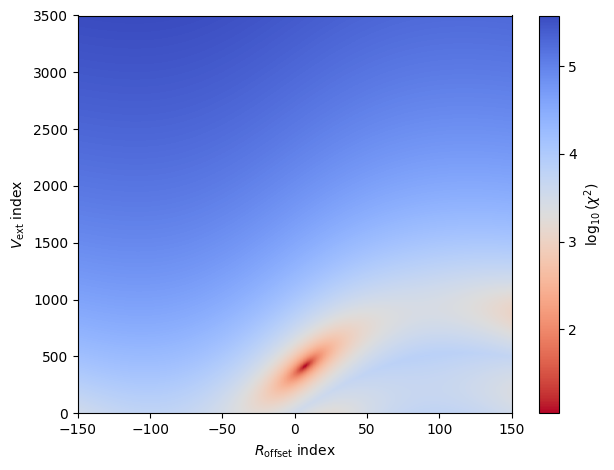

In [7]:
plt.figure()
extent = [-150, 150, 0, 3500]
plt.imshow(np.log10(data), origin="lower", aspect="auto",
           cmap="coolwarm_r", extent=extent)
plt.colorbar(label=r"$\log_{10}(\chi^2)$")
plt.xlabel(r"$R_{\rm offset}$ index")
plt.ylabel(r"$V_{\rm ext}$ index")
plt.tight_layout()
# plt.savefig("test.pdf", dpi=450)
plt.show()

In [14]:
data = {}
for profile in ["exp", "gauss", "mb"]:
    r, __, __, Vmag = main_sergij(profile)
    data[profile] = r, Vmag



2025-04-19 19:56:52,159 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_exp_vx.hdf5`.
2025-04-19 19:56:59,179 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_exp_vy.hdf5`.
2025-04-19 19:57:06,198 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_exp_vrad.hdf5`.
2025-04-19 19:57:13,195 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_exp_density.hdf5`.
2025-04-19 19:57:24,412 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_gauss_vx.hdf5`.
2025-04-19 19:57:31,279 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_gauss_vy.hdf5`.
2025-04-19 19:57:38,077 loading pre-processed data fr

In [63]:
def get_quadrupole_limits(profile):
    h_out = 0.674

    profile2size = {"exp": 7, "gauss": 6, "mb": 15}
    size = profile2size[profile]

    h_in = csiborgtools.flow.select_void_h(size, profile)
    C = np.sqrt(16 * np.pi / 45) * ((h_in - h_out) / 3000)**2
    d = np.sqrt(1e-5 / C)

    return np.sqrt(0.5) * d, d, np.sqrt(2) * d


In [64]:
for profile in ["exp", "gauss", "mb"]:
    print(profile, get_quadrupole_limits(profile)[1])

exp 394.68862567732185
gauss 498.01241781722473
mb 237.66501331674374


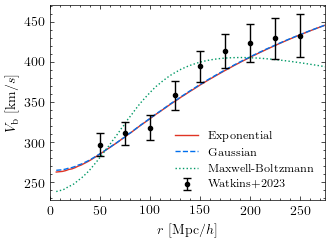

In [22]:
cols = ['#E03424', '#006FED', '#009966']
profiles = ["exp", "gauss", "mb"]
ls = ['-', '--', ':']
labels = ["Exponential", "Gaussian", "Maxwell-Boltzmann"]

with plt.style.context("science"):
    plt.figure()

    for i, profile in enumerate(profiles):
        h_void = csiborgtools.flow.select_void_h(100, profile)
        r, Vmag = data[profile]
        plt.plot(r * h_void, Vmag, color=cols[i], ls=ls[i],
                 label=labels[i])


    r_over_h_watkins = np.array([50.0, 75.0, 100.0, 125.0, 150.0, 175.0, 200.0, 225.0, 250.0])
    bulkflow_watkins =np.array([297.0, 311.0, 318.28218822, 358.20760135, 394.55416487, 413.44319113, 423.37248285, 429.49627515, 432.53804634])
    sigma_1_watkins = np.array([14.0, 14.0, 15.9, 17.5, 19.4, 21.6, 23.7, 25.4, 26.9])
    plt.errorbar(r_over_h_watkins, bulkflow_watkins,
                 yerr=sigma_1_watkins, fmt='o', color="black",
                 label="Watkins+2023", ms=3, capsize=3)

    plt.xlabel(r"$r~[\mathrm{Mpc} / h]$")
    plt.ylabel(r"$V_{\rm b}~[\mathrm{km} / s]$")

    plt.xlim(0, 275)
    plt.legend(fontsize="small")
    plt.tight_layout()
    plt.savefig("void_bulkflow_sergij.pdf", dpi=450)

    plt.show()


/tmp/ipykernel_766953/3251723745.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


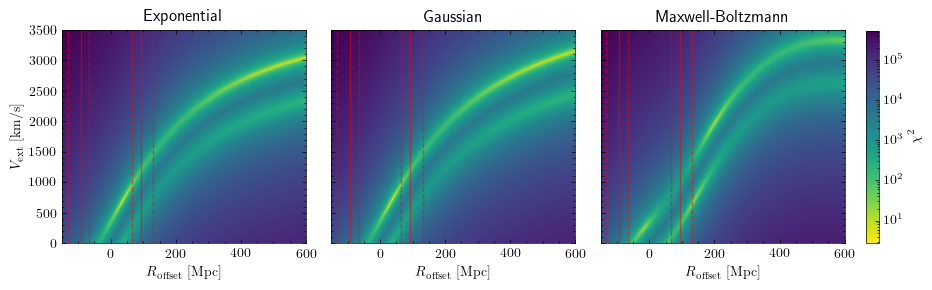

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.cm import ScalarMappable

def get_quadrupole_limits(profile):
    h_out = 0.674
    h_in = csiborgtools.flow.select_void_h(100, profile)
    C = np.sqrt(16 * np.pi / 45) * ((h_in - h_out) / 3000)**2
    d = np.sqrt(1e-5 / C)

    return np.sqrt(0.5) * d, d, np.sqrt(2) * d

kinds = ["EXP", "GAUSS", "MB"]
titles = ["Exponential", "Gaussian", "Maxwell-Boltzmann"]
extent = [-149.99, 600, 0, 3500]
Roffset_range = np.arange(-150, 601)
Vext_range = np.arange(0, 3501)

data_list = []
vmins = []
vmaxs = []
quadrupole_limits = []

# Load all data first
for kind in kinds:
    fpath = f"/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/chi2grids_April2025/ChiSq2D_{kind}profile_voidsize100.dat"
    print(f"Reading the chi2 grid from `{fpath}`.")
    data = np.genfromtxt(fpath)
    data_list.append(data)
    vmins.append(np.nanmin(data[data > 0]))
    vmaxs.append(np.nanmax(data))
    quadrupole_limits.append(get_quadrupole_limits(kind.lower()))

vmin = min(vmins)
vmax = max(vmaxs)

with plt.style.context("science"):
    fig, axes = plt.subplots(1, 3,
                             figsize=(3.5 * 2.5, 3),
                             sharex=True, sharey=True,
                             gridspec_kw={"width_ratios": [1, 1, 1]})
    # fig.subplots_adjust(wspace=0.1)

    norm = LogNorm(vmin=vmin, vmax=vmax)
    cmap = "viridis_r"

    for ax, data, title, quad_lims in zip(axes, data_list, titles, quadrupole_limits):
        im = ax.imshow(data, origin="lower", aspect="auto",
                  cmap=cmap, extent=extent, norm=norm)
    
        xmin, xmed, xmax = quad_lims
        c = "red"
        for sign in [-1, 1]:
            ax.axvline(sign * xmin, color=c, ls="--", alpha=0.5)
            ax.axvline(sign * xmed, color=c, alpha=0.5)
            ax.axvline(sign * xmax, color=c, ls="--", alpha=0.5)


        ax.set_title(title)
        ax.set_xlabel(r"$R_{\rm offset}~[\mathrm{Mpc}]$")
        ax.label_outer()

    axes[0].set_ylabel(r"$V_{\rm ext}~[\mathrm{km}/\mathrm{s}]$")

    # Correct: use ScalarMappable to define colorbar from colormap + norm
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])  # Needed for colorbar to render

    cax = fig.add_axes([0.995, 0.175, 0.015, 0.705])  # Adjust these to taste
    cbar = fig.colorbar(im, cax=cax, format=LogFormatterMathtext())

    cbar.set_label(r"$\chi^2$")
    fig.tight_layout()
    fig.savefig("chi2_grid_fiducial_profiles.pdf", dpi=450)
    fig.show()


Read in samples are:
 ['rLG']


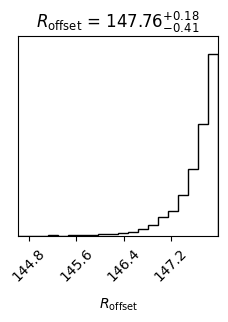

In [10]:
fname = f"/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/ChiSq2D_{kind}profileresolution_3501x601_samples.hdf5"
samples = get_some_samples(fname, ["rLG", "Vmag"])
print("Read in samples are:\n", list(samples.keys()))

data, labels, keys = samples_for_corner(samples)
fig = corner(data, labels=labels, show_titles=True,
             title_kwargs={"fontsize": 12}, smooth=1)

fig.show()

## Paper plots

### Fiducial analysis

#### Posterior ($\beta = 1$)

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoid_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5
Last modified: 13/04/2025 19:55:44
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoid_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5
Last modified: 13/04/2025 20:33:44
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoid_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5
Last modified: 13/04/2025 20:12:05
Removed no burn in


/tmp/ipykernel_3558911/4018040122.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


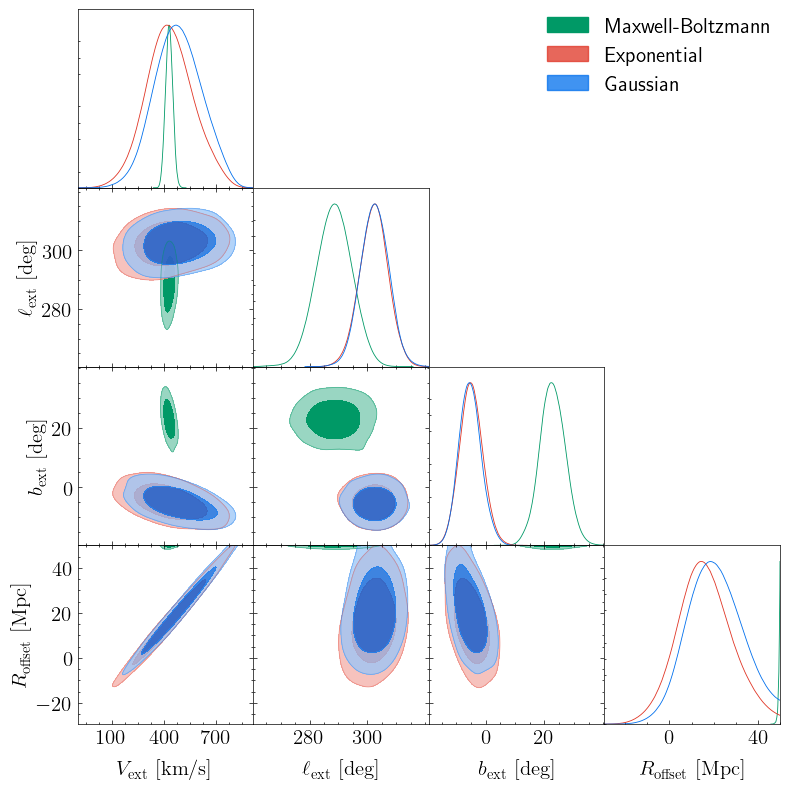

In [33]:
catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']
# catalogue = ['CF4_TFR_w1']
ranges={'rLG': [-50, 50],}
# settings = {'smooth_scale_2D': 0.3, 'smooth_scale_1D': 0.3, 'fine_bins_2D': 1000}
settings = {}

fdir_subfolder = "void_SH0ES_calibrated"
sample_beta = None


X = []
for simname in ["IndranilVoid_mb", "IndranilVoid_exp", "IndranilVoid_gauss"]:
    fname = paths.flow_validation(
        fdir, simname, catalogue, inference_method="mike",
        fdir_subfolder=fdir_subfolder, sample_alpha=False,
        sample_beta=sample_beta, zcmb_max=0.065, remove_CF4_outliers=True)


    samples = get_some_samples(fname, ["rLG", "Vext"] + (["beta"] if sample_beta else []))
    X_i = samples_to_getdist(samples, simname_to_pretty(simname), ranges=ranges, settings=settings)
    X.append(X_i)


# fname = "/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/ChiSq2D_EXPprofileresolution_3501x601_samples.hdf5"
# samples = get_samples(fname, )
# X_i = samples_to_getdist(samples, "Exponential (BF)", settings=settings)
# X.append(X_i)

# fname = "/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/ChiSq2D_GAUSSprofileresolution_3501x601_samples.hdf5"
# samples = get_samples(fname, )
# X_i = samples_to_getdist(samples, "Gauss (BF)", settings=settings)
# X.append(X_i)


params = ["Vmag", "l", "b", "rLG"]
if sample_beta:
    params.append("beta")

with plt.style.context("science"):
    # cols = ['gray', '#009966', '#006FED', '#E03424', '#000866', '#336600', '#006633', 'm', 'r']
    # cols = ['gray', '#009966', '#006FED', '#E03424', '#000866', 'm', 'r', 'm', 'r']
    # cols = ['#006FED', '#E03424', '#006FED', '#E03424'][::-1]
    # jcols = ['#1f77b4', '#d62728', '#2CA02C',]#[::-1]

    cols = ['#006FED', '#E03424', '#009966']

    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    g.settings.solid_colors = cols
    g.settings.legend_fontsize = 18
    g.settings.axes_labelsize = 18
    g.settings.axes_fontsize = 18
    # g.settings.line_styles = ['-', '-', '--', '--']

    g.triangle_plot(X, params=params,
                    filled = True,
                    # filled=[True, True, False, False],
                    # contour_colors=cols,
                    legend_loc='upper right',)
    plt.gcf().tight_layout()
    plt.gcf().show()
    plt.gcf().savefig(f"../../../plots/void_fiducial.pdf", dpi=500, bbox_inches='tight')

### Fiducial, comparison to Sergij

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 14/04/2025 00:24:08
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 13/04/2025 21:19:17
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 13/04/2025 21:16:47
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


/tmp/ipykernel_14000/2307673627.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


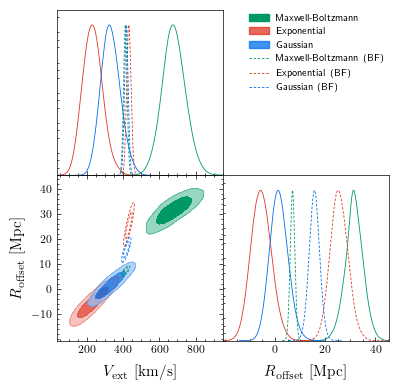

In [10]:
catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']
# catalogue = ['CF4_TFR_w1']
ranges={'rLG': [-50, 50],}
# settings = {'smooth_scale_2D': 0.3, 'smooth_scale_1D': 0.3, 'fine_bins_2D': 1000}
settings = {}

fdir_subfolder = "void_SH0ES_calibrated"
sample_beta = True


X = []
# for simname in ["IndranilVoid_mb", "IndranilVoid_exp", "IndranilVoid_gauss"]:
for simname in ["IndranilVoidSizeVar_mb", "IndranilVoidSizeVar_exp", "IndranilVoidSizeVar_gauss"]:
    fname = paths.flow_validation(
        fdir, simname, catalogue, inference_method="mike",
        fdir_subfolder=fdir_subfolder, sample_alpha=False,
        sample_beta=sample_beta, zcmb_max=0.065, remove_CF4_outliers=True,
        which_void_size_run="zoom",
        )


    samples = get_some_samples(fname, ["rLG", "Vext"] + (["beta"] if sample_beta else []))
    X_i = samples_to_getdist(samples, simname_to_pretty(simname), ranges=ranges, settings=settings)
    X.append(X_i)

fname = "/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/chi2grids_April2025/ChiSq2D_MBprofile_voidsize15_samples.hdf5"
# fname = "/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/chi2grids_April2025/ChiSq2D_MBprofile_voidsize100_samples.hdf5"
samples = get_samples(fname, )
X_i = samples_to_getdist(samples, "Maxwell-Boltzmann (BF)", settings=settings)
# X_i = samples_to_getdist(samples, None, settings=settings)
X.append(X_i)

fname = "/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/chi2grids_April2025/ChiSq2D_EXPprofile_voidsize6_samples.hdf5"
# fname = "/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/chi2grids_April2025/ChiSq2D_EXPprofile_voidsize100_samples.hdf5"
samples = get_samples(fname, )
X_i = samples_to_getdist(samples, "Exponential (BF)", settings=settings)
# X_i = samples_to_getdist(samples, None, settings=settings)
X.append(X_i)

fname = "/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/chi2grids_April2025/ChiSq2D_GAUSSprofile_voidsize6_samples.hdf5"
# fname = "/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/chi2grids_April2025/ChiSq2D_GAUSSprofile_voidsize100_samples.hdf5"
samples = get_samples(fname, )
X_i = samples_to_getdist(samples, "Gaussian (BF)", settings=settings)
# X_i = samples_to_getdist(samples, None, settings=settings)
X.append(X_i)


params = ["Vmag", "rLG"]
# if sample_beta:
    # params.append("beta")

with plt.style.context("science"):
    # cols = ['gray', '#009966', '#006FED', '#E03424', '#000866', '#336600', '#006633', 'm', 'r']
    # cols = ['gray', '#009966', '#006FED', '#E03424', '#000866', 'm', 'r', 'm', 'r']
    # cols = ['#006FED', '#E03424', '#006FED', '#E03424'][::-1]
    # cols = ['#009966', '#006FED', '#E03424', '#009966', '#006FED', '#E03424'][::-1]

    # cols = ['#d62728', '#1f77b4', '#2CA02C', '#d62728', '#1f77b4', '#2CA02C'][::-1]
    # cols = ['#d62728', '#1f77b4', '#2CA02C', '#d62728', '#1f77b4', '#2CA02C'][::-1]

    # cols = ['#1f77b4', '#d62728', '#2CA02C',]
    cols = ['#006FED', '#E03424', '#009966']
    cols = (cols + cols)[::-1]

    # cols[0] = "#d62728"
    # cols[1] = "#1f77b4"
    # cols[2] = "#2CA02C"

    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    # g.settings.solid_colors = cols
    g.settings.legend_fontsize = 10.
    # g.settings.axes_labelsize = 18
    # g.settings.axes_fontsize = 18
    # g.settings.line_styles = [ '-', '-', '--', '--',]
    g.settings.line_styles = [ '-', '-', '-', '--', '--', '--']

    g.triangle_plot(X, params=params,
                    # filled = True,
                    filled=[True, True, True, False, False, False],
                    # filled=[True, True, False, False],
                    contour_colors=cols,
                    legend_loc='upper right',)
    plt.gcf().tight_layout()
    plt.gcf().show()
    plt.gcf().savefig(f"../../../plots/void_size_comparison.pdf", dpi=500, bbox_inches='tight')
    # plt.gcf().savefig(f"../../../plots/void_fiducial_comparison.pdf", dpi=500, bbox_inches='tight')

### Tension between my and BF constrain

In [11]:
catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']

fdir_subfolder = "void_SH0ES_calibrated"
sample_beta = True


fname = paths.flow_validation(
    fdir, "IndranilVoid_mb", catalogue, inference_method="mike",
    fdir_subfolder=fdir_subfolder, sample_alpha=False,
    sample_beta=sample_beta, zcmb_max=0.065, remove_CF4_outliers=True)

samples_mine = get_some_samples(fname, ["rLG", "Vext"] + (["beta"] if sample_beta else []))

samples_mine = np.vstack([samples_mine["rLG"], samples_mine["Vmag"]]).T


# fname = "/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/chi2grids_April2025/ChiSq2D_GAUSSprofile_voidsize100_samples.hdf5"
# fname = "/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/chi2grids_April2025/ChiSq2D_EXPprofile_voidsize100_samples.hdf5"
fname = "/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/chi2grids_April2025/ChiSq2D_MBprofile_voidsize15_samples.hdf5"
samples_bf = get_samples(fname, )
samples_bf = np.vstack([samples_bf["rLG"], samples_bf["Vmag"]]).T

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoid_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_remove_CF4_outliers.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

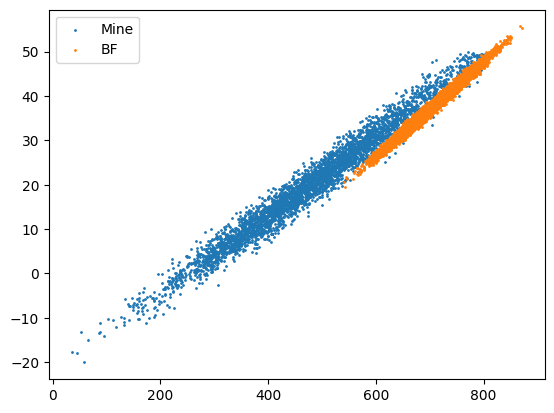

In [12]:
plt.figure()
plt.scatter(samples_mine[:, 1], samples_mine[:, 0], label="Mine", s=1)
plt.scatter(samples_bf[:, 1], samples_bf[:, 0], label="BF", s=1)
plt.legend()
plt.show()

In [13]:
import posterior_agreement
agreement_2d_1 = posterior_agreement.compute_agreement((samples_mine, samples_bf), nSamples=100000, nBins=60)
print("Example one: PTE %.3f, %.3fσ"%(agreement_2d_1.PTE, agreement_2d_1.sigma))

Example one: PTE 0.107, 1.612σ


In [ ]:
# exponential: 1.746σ
# Gaussian  1.612σ

#### Predicted void summary statistics

Using h_void = 0.7733393599999999 for profile `exp`.
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoid_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5
Last modified: 13/04/2025 20:33:44


/mnt/users/rstiskalek/csiborgtools/notebooks/flow/paper_void/../reconstruction_comparison.py:34: RuntimeWarning: invalid value encountered in divide
  dec = np.arcsin(z / d)


2025-04-17 22:55:57,857 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_exp_vx.hdf5`.
2025-04-17 22:56:04,609 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_exp_vy.hdf5`.
2025-04-17 22:56:11,077 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_exp_vrad.hdf5`.
2025-04-17 22:56:17,559 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_exp_density.hdf5`.


/mnt/users/rstiskalek/csiborgtools/venv_csiborg/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


Using h_void = 0.7732155199999999 for profile `gauss`.
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoid_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5
Last modified: 13/04/2025 20:12:05
2025-04-17 22:56:28,617 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_gauss_vx.hdf5`.
2025-04-17 22:56:35,307 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_gauss_vy.hdf5`.
2025-04-17 22:56:42,077 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_gauss_vrad.hdf5`.
2025-04-17 22:56:48,778 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_gauss_density.hdf5`.
Using h_void = 0.77273875 for profile `mb`.
File:          /mnt/e

/tmp/ipykernel_57394/346123677.py:85: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  fig.tight_layout()


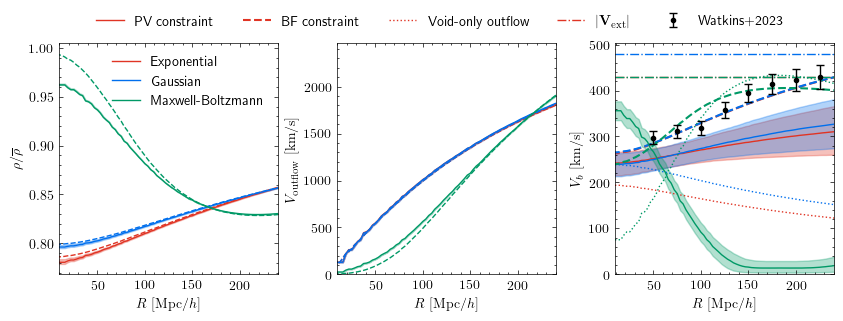

In [ ]:
profiles = ["exp", "gauss", "mb"]
fdir_subfolder = "void_SH0ES_calibrated"
sample_beta = None
cols = ['#E03424', '#006FED', '#009966']


with plt.style.context("science"):
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))
    fig.subplots_adjust(wspace=0.27)
    lw = plt.rcParams['lines.linewidth']

    for n in range(len(profiles)):
        profile = profiles[n]
        c = cols[n]
        h_void = csiborgtools.flow.select_void_h(100, profile)
        print(f"Using h_void = {h_void} for profile `{profile}`.")

        simname = f"IndranilVoid_{profile}"
        fname = paths.flow_validation(
            fdir, simname, catalogue, inference_method="mike",
            fdir_subfolder=fdir_subfolder, sample_alpha=False,
            sample_beta=sample_beta, zcmb_max=0.065, remove_CF4_outliers=True)

        r, rho, Vmono, Vbulk, Vbulk_void, Vext, Vmag_l, Vmag_b = read_void_stats_per_sample(fname)
        r = r * h_void

        ylow, ymed, yhigh = np.percentile(rho, [16, 50, 84], axis=0)
        axs[0].plot(r, ymed, color=c, label=simname_to_pretty(simname))
        axs[0].fill_between(r, ylow, yhigh, alpha=0.3, color=c)
        axs[0].set_ylabel(r"$\rho / \overline{\rho}$")

        ylow, ymed, yhigh = np.percentile(Vmono, [16, 50, 84], axis=0)
        axs[1].plot(r, ymed, color=c)
        axs[1].fill_between(r, ylow, yhigh, alpha=0.3, color=c)
        axs[1].set_ylabel(r"$V_{\rm outflow} ~ [\mathrm{km} / \mathrm{s}]$")


        ylow, ymed, yhigh = np.percentile(Vbulk, [16, 50, 84], axis=0)
        axs[2].plot(r, ymed, label="PV constraint" if n == 0 else None,
                    color=c)
        axs[2].fill_between(r, ylow, yhigh, alpha=0.3, color=c)

        # if profile != "mb":
        r_bf, rho_bf, vmono_bf, vmag_bf = main_sergij(profile)

        axs[0].plot(r_bf * h_void, rho_bf, color=c, ls="--")
        axs[1].plot(r_bf * h_void, vmono_bf, color=c, ls="--")
        axs[2].plot(r_bf * h_void, vmag_bf,
                    label="BF constraint" if n == 0 else None,
                    color=c, ls="--", lw=1.5*lw)

        # Void bulk flow only
        ymed = np.nanmedian(Vbulk_void, axis=0)
        axs[2].plot(r, ymed, c=c, ls="dotted", label="Void-only outflow" if n == 0 else None)

        # Vext flow magnitude only
        ymed = np.median(Vext, axis=0)
        axs[2].axhline(ymed, c=c, ls="dashdot", label=r"$|\mathbf{V}_{\rm ext}|$" if n == 0 else None)


    r_over_h_watkins = np.array([50.0, 75.0, 100.0, 125.0, 150.0, 175.0, 200.0, 225.0, 250.0])
    bulkflow_watkins =np.array([297.0, 311.0, 318.28218822, 358.20760135, 394.55416487, 413.44319113, 423.37248285, 429.49627515, 432.53804634])
    sigma_1_watkins = np.array([14.0, 14.0, 15.9, 17.5, 19.4, 21.6, 23.7, 25.4, 26.9])
    axs[2].errorbar(r_over_h_watkins, bulkflow_watkins,
                    yerr=sigma_1_watkins, fmt='o', color="black",
                    label="Watkins+2023", ms=3, capsize=3)

    axs[2].set_ylabel(r"$V_b ~ [\mathrm{km} / \mathrm{s}]$")


    ii, jj = np.where(np.isfinite(Vmono[0]))[0][[0, -1]]
    for n in range(3):
        axs[n].set_xlim(r[ii], 240)

    axs[0].legend(loc="upper right")
    axs[2].legend(ncols=5, loc="lower center", bbox_to_anchor=(-0.8, 1.01))
    axs[1].set_ylim(0)
    axs[2].set_ylim(0)

    for ax in axs:
        ax.set_xlabel(r"$R ~ [\mathrm{Mpc} / h]$")

    fig.tight_layout()
    fig.savefig("../../../plots/bulk_flow_fiducial.pdf", dpi=300, bbox_inches='tight')
    fig.show()


In [13]:
!ls /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoid_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers_stats*

/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoid_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers_stats.hdf5


In [ ]:
/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/SH0ES_void_calibrated/samples_IndranilVoid_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers_stats.hdf5
/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoid_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers_stats.hdf5

In [27]:
# profile = "gauss"
for profile in ["gauss", "exp", "mb"]:
    fname = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_{profile}_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5"
    x = get_some_samples(fname, ["beta"])

    # x["l"].mean(), x["b"].mean(), x["Vmag"].mean(), x["Vmag"].std()
    print(profile, x["beta"].mean(), x["beta"].std())

gauss 1.6436205 0.11958437
exp 2.1499364 0.1634421
mb 0.7225746 0.06187674


File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 22/03/2025 02:00:34
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 16/03/2025 20:54:36
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 17/03/2025 06:30:08
Removed no burn in


/tmp/ipykernel_1659514/2671523374.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


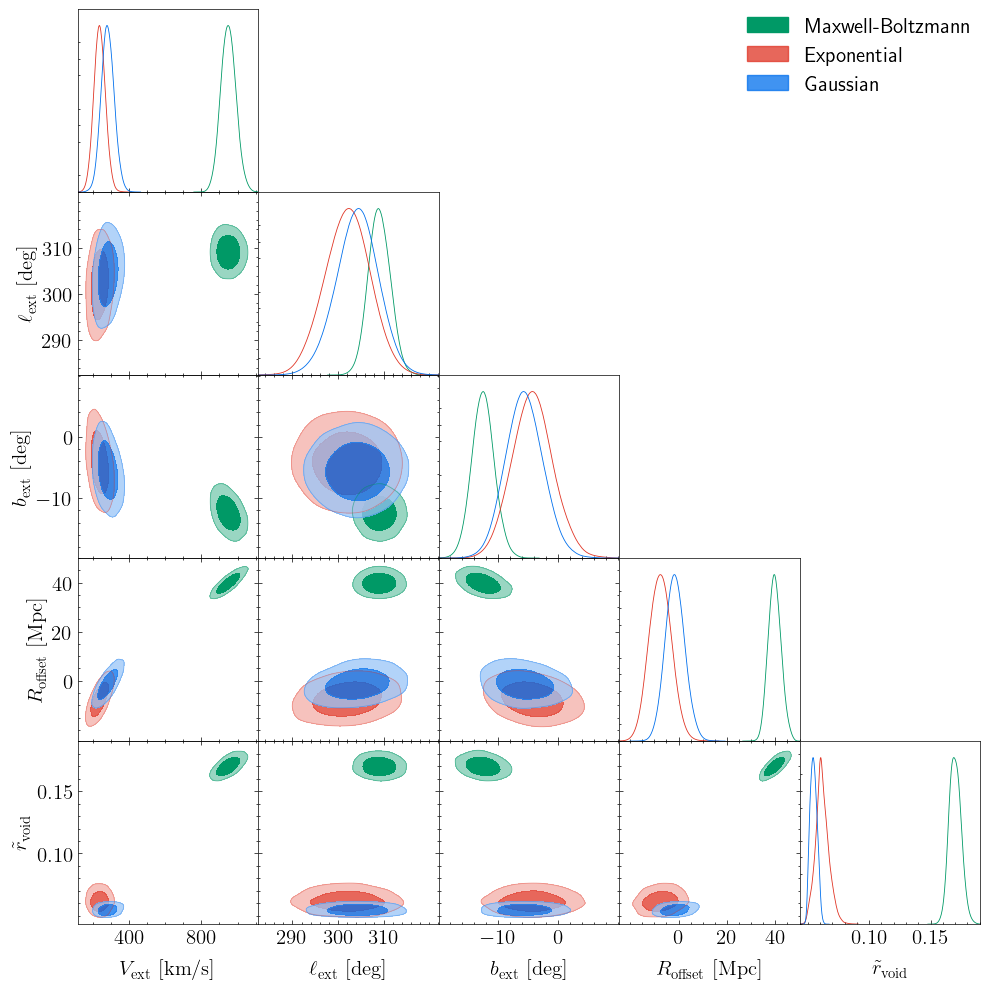

In [4]:
catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']
# catalogue = ['CF4_TFR_w1']

ranges_zoom = {
    'void_size':[0.01, 0.2],
    # 'void_size':[0.1, 3.0],
    'rLG': [-50, 50],
    }

ranges_coarse = {
    'void_size':[0.01, 3.0],
    'rLG': [-50, 50],
    }



X = []
for simname in ["IndranilVoidSizeVar_mb", "IndranilVoidSizeVar_exp", "IndranilVoidSizeVar_gauss", ]:
    # fname = paths.flow_validation(
    #     fdir, simname, catalogue, fdir_subfolder="void_SH0ES_calibrated",
    #     inference_method="mike", sample_alpha=False, sample_beta=True, 
    #     zcmb_max=0.065, which_void_size_run="zoom",
    #     remove_CF4_outliers=True)
    fname = paths.flow_validation(
        fdir, simname, catalogue, fdir_subfolder="void",
        inference_method="mike", sample_alpha=False, sample_beta=None, 
        zcmb_max=0.065, which_void_size_run="zoom",
        remove_CF4_outliers=True)

    ranges = ranges_zoom

    samples = get_some_samples(fname, ["rLG", "Vext", "void_size", "beta"])
    X_i = samples_to_getdist(samples, simname_to_pretty(simname), ranges=ranges)
    X.append(X_i)


# params = ["Vmag", "l", "b", "rLG", "void_size"]
cols = ['#006FED', '#E03424', '#009966']
with plt.style.context("science"):
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    g.settings.solid_colors = cols
    g.settings.legend_fontsize = 18
    g.settings.axes_labelsize = 18
    g.settings.axes_fontsize = 18

    g.triangle_plot(X, filled=True, legend_loc='upper right')
    plt.gcf().tight_layout()
    plt.gcf().show()
    plt.gcf().savefig(f"../../../plots/void_extended_no_calibration.pdf", dpi=500, bbox_inches='tight')

#### Gaussian plot restricted to large sizes 

#### Void statistics

In [5]:
cols = sns.color_palette()
cols[0] = "#d62728"
cols[1] = "#1f77b4"
cols[2] = "#2CA02C"


Using h_void = 0.6917265899999999 for profile `exp`.
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 13/04/2025 21:19:17
2025-05-12 05:15:31,748 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_exp_vx.hdf5`.
2025-05-12 05:15:38,313 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_exp_vy.hdf5`.
2025-05-12 05:15:46,076 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_exp_vrad.hdf5`.
2025-05-12 05:15:54,910 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_exp_density.hdf5`.


/mnt/users/rstiskalek/csiborgtools/venv_csiborg/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


Using h_void = 0.6925296299999999 for profile `gauss`.
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 13/04/2025 21:16:47


/mnt/users/rstiskalek/csiborgtools/notebooks/flow/paper_void/../reconstruction_comparison.py:34: RuntimeWarning: invalid value encountered in divide
  dec = np.arcsin(z / d)


2025-05-12 05:16:08,409 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_gauss_vx.hdf5`.
2025-05-12 05:16:14,947 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_gauss_vy.hdf5`.
2025-05-12 05:16:21,501 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_gauss_vrad.hdf5`.
2025-05-12 05:16:28,023 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_gauss_density.hdf5`.
Using h_void = 0.72850523 for profile `mb`.
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 14/04/2025 00:24:08
2025-05-12 05:16:39,377 loading pre

/tmp/ipykernel_14000/904869456.py:102: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  fig.tight_layout()


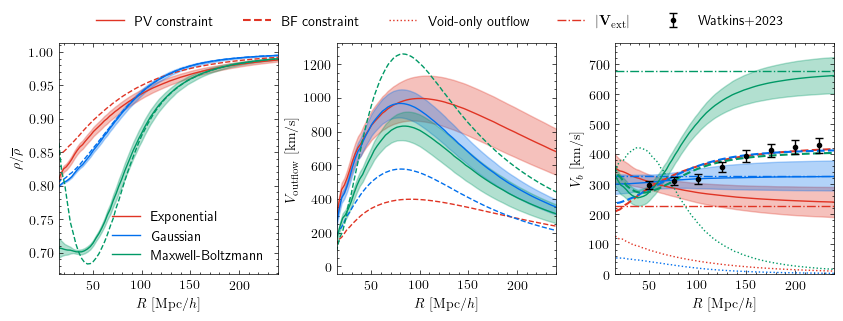

In [14]:
from scipy.signal import savgol_filter

profiles = ["exp", "gauss", "mb"]
void_size = [6, 6, 18]
catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']


def smooth_stats(ylow, ymed, yhigh, window_length=5, polyorder=3):
    ymed = savgol_filter(ymed, window_length, polyorder)
    ylow = savgol_filter(ylow, window_length, polyorder)
    yhigh = savgol_filter(yhigh, window_length, polyorder)
    return ylow, ymed, yhigh


with plt.style.context("science"):
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))
    fig.subplots_adjust(wspace=0.27)
    cols = ['#E03424', '#006FED', '#009966']
    lw = plt.rcParams['lines.linewidth']

    for n in range(len(profiles)):
        profile = profiles[n]
        c = cols[n]
        h_void = csiborgtools.flow.select_void_h(void_size[n], profile)
        print(f"Using h_void = {h_void} for profile `{profile}`.")

        simname = f"IndranilVoidSizeVar_{profile}"
        # fname = paths.flow_validation(
        #    fdir, simname, catalogue, fdir_subfolder="void_SH0ES_calibrated",
        #    inference_method="mike", sample_alpha=False, sample_beta=True, 
        #    zcmb_max=0.065, which_void_size_run="zoom",
        #    remove_CF4_outliers=True)
        fname = paths.flow_validation(
            fdir, simname, catalogue, fdir_subfolder="void_SH0ES_calibrated",
            inference_method="mike", sample_alpha=False, sample_beta=True, 
            zcmb_max=0.065, which_void_size_run="zoom",
            remove_CF4_outliers=True)

        r, rho, Vmono, Vbulk, Vbulk_void, Vext, __, __  = read_void_stats_per_sample(fname)
        r = r * h_void

        ylow, ymed, yhigh = np.percentile(rho, [16, 50, 84], axis=0)
        ystd = np.std(rho, axis=0)
        ylow = ymed - ystd
        yhigh = ymed + ystd
        ylow, ymed, yhigh = smooth_stats(ylow, ymed, yhigh)
        axs[0].plot(r, ymed, color=c, label=simname_to_pretty(simname))
        axs[0].fill_between(r, ylow, yhigh, alpha=0.3, color=c)
        axs[0].set_ylabel(r"$\rho / \overline{\rho}$")

        ylow, ymed, yhigh = np.percentile(Vmono, [16, 50, 84], axis=0)
        ystd = np.std(Vmono, axis=0)
        ylow = ymed - ystd
        yhigh = ymed + ystd
        ylow, ymed, yhigh = smooth_stats(ylow, ymed, yhigh)
        axs[1].plot(r, ymed, color=c)
        axs[1].fill_between(r, ylow, yhigh, alpha=0.3, color=c)
        axs[1].set_ylabel(r"$V_{\rm outflow} ~ [\mathrm{km} / \mathrm{s}]$")


        ylow, ymed, yhigh = np.percentile(Vbulk, [16, 50, 84], axis=0)
        ylow, ymed, yhigh = smooth_stats(ylow, ymed, yhigh)
        axs[2].plot(r, ymed, label="PV constraint" if n == 0 else None,
                    color=c)
        axs[2].fill_between(r, ylow, yhigh, alpha=0.3, color=c)

        r_bf, rho_bf, vmono_bf, vmag_bf = mainsizevar_sergij(profile)
        axs[0].plot(r_bf * h_void, rho_bf, color=c, ls="--")
        axs[1].plot(r_bf * h_void, vmono_bf, color=c, ls="--")
        axs[2].plot(r_bf * h_void, vmag_bf,
                    label="BF constraint" if n == 0 else None,
                    color=c, ls="--", lw=1.5*lw)

        # Void bulk flow only
        ymed = np.nanmedian(Vbulk_void, axis=0)
        axs[2].plot(r, ymed, c=c, ls="dotted", label="Void-only outflow" if n == 0 else None)

        # Vext flow magnitude only
        ymed = np.median(Vext, axis=0)
        axs[2].axhline(ymed, c=c, ls="dashdot", label=r"$|\mathbf{V}_{\rm ext}|$" if n == 0 else None)


    r_over_h_watkins = np.array([50.0, 75.0, 100.0, 125.0, 150.0, 175.0, 200.0, 225.0, 250.0])
    bulkflow_watkins =np.array([297.0, 311.0, 318.28218822, 358.20760135, 394.55416487, 413.44319113, 423.37248285, 429.49627515, 432.53804634])
    sigma_1_watkins = np.array([14.0, 14.0, 15.9, 17.5, 19.4, 21.6, 23.7, 25.4, 26.9])
    axs[2].errorbar(r_over_h_watkins, bulkflow_watkins, yerr=sigma_1_watkins,
                    fmt='o', color="black", label="Watkins+2023", ms=3,
                    capsize=3)

    axs[0].legend()
    axs[2].set_ylim(0)
    axs[2].set_ylabel(r"$V_b ~ [\mathrm{km} / \mathrm{s}]$")

    ii, jj = np.where(np.isfinite(Vmono[0]))[0][[0, -1]]
    for n in range(3):
        axs[n].set_xlim(r[ii + 2], 240)
        axs[n].set_xlabel(r"$R ~ [\mathrm{Mpc} / h]$")

    axs[0].legend(loc="lower right")
    axs[2].legend(ncols=5, loc="lower center", bbox_to_anchor=(-0.8, 1.01))

    fig.tight_layout()
    fig.savefig("../../../plots/bulk_flow_vary_size.pdf", dpi=300)
    fig.show()

### Predited void $H_0$

#### $H_0$ PPD

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 13/04/2025 21:19:17
exp med H0 = 72.08333 + 0.86077 - 0.80483 km/s/Mpc
exp mean beta = 2.14994 ± 0.16344
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 13/04/2025 21:16:47
gauss med H0 = 70.40168 + 0.43146 - 0.38340 km/s/Mpc
gauss mean beta = 1.64362 ± 0.11958
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modifi

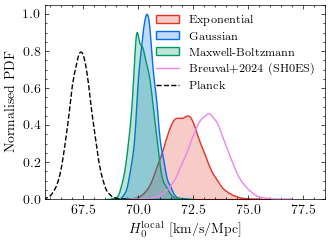

In [10]:
from interpax import Interpolator1D

profiles = ["exp", "gauss", "mb"]
cols = ['#E03424', '#006FED', '#009966']
catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']

with plt.style.context("science"):
    plt.figure()

    for n in range(len(profiles)):
        profile = profiles[n]
        simname = f"IndranilVoidSizeVar_{profile}"
        fname = paths.flow_validation(
           fdir, simname, catalogue,
           fdir_subfolder="void_SH0ES_calibrated",
        #    fdir_subfolder="void",
           inference_method="mike", sample_alpha=False, sample_beta=True, 
           zcmb_max=0.065, which_void_size_run="zoom", remove_CF4_outliers=True)

        void_size, h_void = csiborgtools.flow.select_void_h(
            None, profile, return_all=True)

        beta = get_some_samples(fname, ["beta"])["beta"]

        # Check if the mapping is in H0 or h and sizes in percent
        void_size_to_h_void = Interpolator1D(
            void_size / 100, h_void, method="linear")

        with File(fname, 'r') as f:
            void_size = f["samples/void_size"][...]

        h_void = void_size_to_h_void(void_size)
        h_void = 0.674 + (h_void - 0.674) * beta

        
        H = 100 * h_void
        low, med, high = np.percentile(H, [16, 50, 84], axis=0)
        print(profile, f"med H0 = {med:.5f} + {high - med:.5f} - {med - low:.5f} km/s/Mpc")
        print(profile, f"mean beta = {beta.mean():.5f} ± {beta.std():.5f}")
        # print(profile, 100 * h_void.mean(), 100 * h_void.std())

        sns.kdeplot(h_void * 100,
                    label=simname_to_pretty(f"IndranilVoid_{profile}"),
                    fill=True, color=cols[n])

    from scipy.stats import norm 
    x = norm(73.17, 0.86).rvs(30_000)
    sns.kdeplot(x, label="Breuval+2024 (SH0ES)", fill=False, color="violet")

    x = norm(67.4, 0.5).rvs(30_000)
    sns.kdeplot(x, label="Planck", fill=False, color="k", ls="--")

    plt.xlim(65.8, 78.5)

    plt.xlabel(r"$H_0^{\rm local} ~ [\mathrm{km} / \mathrm{s} / \mathrm{Mpc}]$")
    plt.ylabel("Normalised PDF")
    plt.legend(fontsize="small")
    plt.tight_layout()
    plt.savefig("h_void_distribution.pdf", dpi=300)
    plt.show()

#### $H_0$ dependence on the void size

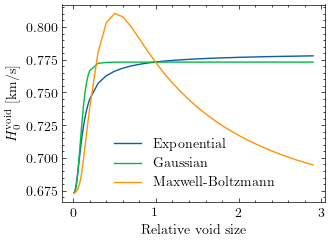

In [49]:
with plt.style.context("science"):
    plt.figure()
    for profile in ["exp", "gauss", "mb"]:
        void_size, h_void = csiborgtools.flow.select_void_h(
                 None, profile, return_all=True)
        m = void_size < 300
        plt.plot(void_size [m]/ 100, h_void[m],
                 label=simname_to_pretty(f"IndranilVoid_{profile}"))
    plt.xlabel("Relative void size")
    plt.ylabel(r"$H_0^{\rm void} ~ [\mathrm{km} / \mathrm{s}]$")
    plt.legend()

    plt.tight_layout()
    # plt.savefig("../../plots/h_void_vs_void_size.png", dpi=300)
    plt.show()


### Evidence comparison

In [ ]:
catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']

X = {}
for simname in ["no_field_300",
                "IndranilVoid_exp",
                "IndranilVoid_gauss",
                "IndranilVoid_mb",
                "IndranilVoidSizeVar_exp",
                "IndranilVoidSizeVar_gauss",
                "IndranilVoidSizeVar_mb",
                ]:
    # print(simname)

    if "SizeVar" in simname:
        if "_mb" in simname:
            which_void_size_run = "coarse"
        else:
            which_void_size_run = "zoom"
    else:
        which_void_size_run = None


    fname = paths.flow_validation(
        fdir, simname, catalogue, fdir_subfolder="void",
        inference_method="mike",
        sample_alpha=False, sample_beta=None, no_Vext=None,
        zcmb_max=0.065, remove_CF4_outliers=True,
        which_void_size_run=which_void_size_run,
        )
    
    if "SizeVar" in simname:
        x = get_some_samples(fname, ["void_size"])
        print(simname, x["void_size"].mean(), x["void_size"].std())
        

    X[simname] = -get_gof("neg_lnZ_harmonic", fname) / np.log(10)


# for simname in ["Carrick2015", "CF4"]:
#     fname = paths.flow_validation(
#         fdir, simname, catalogue, 
#         inference_method="mike", remove_CF4_outliers=True,
#         sample_alpha=True, sample_beta=None,
#         zcmb_max=0.065)
#     X[simname] = - get_gof("neg_lnZ_harmonic", fname) / np.log(10)

# Take 'IndranilVoid_gass' as a reference
ref = X["no_field_300"]
for key in X:
    X[key] -= ref

# for key in list(X.keys()):
    # val = X.pop(key)
    # X[simname_to_pretty(key)] = round(val, 2)

print()
for key, val in X.items():
    print(f"{key}: {val}")

no_field_300
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_no_field_300_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5
Last modified: 23/03/2025 23:59:36
IndranilVoid_exp
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoid_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5
Last modified: 18/03/2025 15:40:28
IndranilVoid_gauss
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoid_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5
Last modified: 18/03/2025 15:33:57
IndranilVoid_mb
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoid_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5
Last modified: 18/03/2025 14:22:20
IndranilVoidSizeVar_exp
File:          /mnt/extras

#### Evidence dependence on the void size 

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoid1_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_remove_CF4_outliers.hdf5
Last modified: 20/04/2025 11:34:34
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoid2_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_remove_CF4_outliers.hdf5
Last modified: 20/04/2025 11:42:41
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoid3_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_remove_CF4_outliers.hdf5
Last modified: 20/04/2025 11:36:55
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoid4_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_remove_CF4_outliers.hdf5
Last modified: 20/04/2025 1

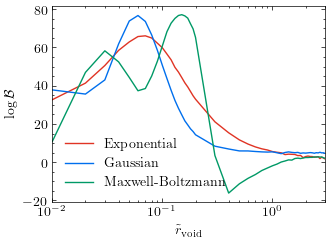

In [11]:
catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']
cols = ['#E03424', '#006FED', '#009966']

sizes = np.asarray([n for n in range(1, 20)] + [10 * n for n in range(2, 31)])

def void_gof_sizevar(kind, gof):
    y = np.full_like(sizes, np.nan, dtype=float)
    for i, size in enumerate(sizes):
        simname = f"IndranilVoid{size}_{kind}"
        fname = paths.flow_validation(
            fdir, simname, catalogue, fdir_subfolder="void_SH0ES_calibrated",
            inference_method="mike",
            sample_alpha=False, sample_beta=True, 
            zcmb_max=0.065, verbose_print=True, remove_CF4_outliers=True,)
        if exists(fname):
            y[i] = get_gof(gof, fname)
    return y

logZ = - np.stack([
    void_gof_sizevar("exp", "neg_lnZ_harmonic"),
    void_gof_sizevar("gauss", "neg_lnZ_harmonic"),
    void_gof_sizevar("mb", "neg_lnZ_harmonic"),
                   ])
logZ /= np.log(10)


fname = paths.flow_validation(
    fdir, "no_field_300", catalogue, fdir_subfolder="void_SH0ES_calibrated",
    inference_method="mike",
    sample_alpha=False, sample_beta=None, 
    zcmb_max=0.065, verbose_print=True, remove_CF4_outliers=True,
    sample_h_tilde=True
    )

ref = -get_gof("neg_lnZ_harmonic", fname) / np.log(10)

# m = np.isfinite(logZ[2])
# from scipy.interpolate import interp1d
# logZ[2, ~m] = interp1d(sizes[m], logZ[2, m], kind="cubic")(sizes[~m])
sizes = sizes / 100
logZ -= ref


with plt.style.context("science"):
    plt.figure()
    m = sizes > 0
    plt.plot(sizes[m], logZ[0][m],
             label=simname_to_pretty("IndranilVoid_exp"), c=cols[0])
    plt.plot(sizes[m], logZ[1][m],
             label=simname_to_pretty("IndranilVoid_gauss"), c=cols[1])
    plt.plot(sizes[m], logZ[2][m],
             label=simname_to_pretty("IndranilVoid_mb"), c=cols[2])

    plt.xlim(sizes.min(), sizes.max())
    plt.xlabel(r"$\tilde{r}_{\rm void}$")
    plt.ylabel(r"$\log \mathcal{B}$")
    plt.legend()
    # plt.axvline(0.2)
    plt.xscale("log")

    plt.tight_layout()
    plt.savefig("../../../plots/void_size_var.pdf", dpi=300)
    plt.show()



In [10]:
ref

50229.50564971763

array([-25840.05175304, -25832.72981951, -25809.60872774, -25792.55418701,
       -25803.19609828, -25827.40462272, -25838.67422523,            -inf,
       -25844.50496794, -25816.57270761, -25795.1463822 , -25779.53892426,
       -25767.11572702, -25757.2932073 , -25750.69227047, -25747.08050112,
       -25746.25941312, -25747.85578463, -25750.31735218, -25754.84351499,
       -25825.24332909, -25869.5430627 , -25893.64640645, -25907.55909804,
       -25914.40771844, -25917.11188018, -25917.75823251, -25916.8641966 ,
       -25915.29157557, -25912.59589615, -25905.36726807, -25901.44165311,
       -25898.26587471, -25894.95268282, -25891.47493404, -25888.6571093 ,
       -25885.54749295, -25883.05708553, -25880.68373404, -25878.74128411,
       -25876.4561487 , -25874.61548654, -25873.1158134 , -25871.8248052 ,
       -25870.52361821, -25868.38777152, -25867.5582012 , -25865.94147214])

### Extended analysis, varying the void size and $\beta$

#### Corner plot

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_exp_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05_sample_beta_which_void_size_run_zoom.hdf5
Last modified: 19/12/2024 15:27:59
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_gauss_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05_sample_beta_which_void_size_run_zoom.hdf5
Last modified: 19/12/2024 13:08:11
Removed no burn in


/tmp/ipykernel_1947110/1037148779.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


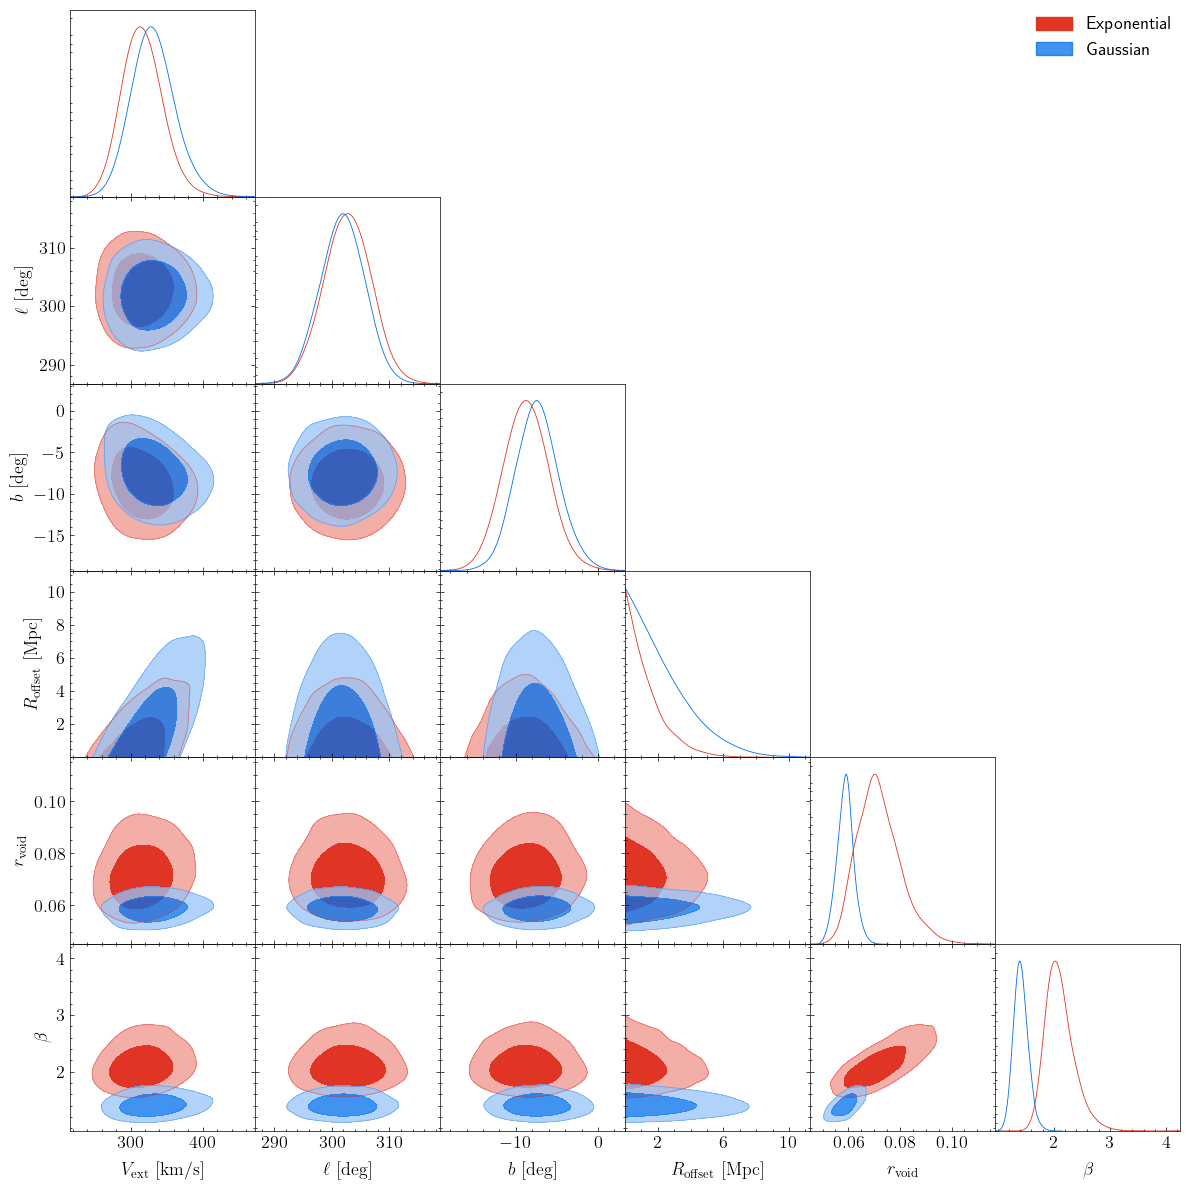

In [ ]:
catalogue = ['LOSS', 'Foundation', 'CF4_TFR_i', 'CF4_TFR_notSDSS_w1']

ranges={
    'void_size':[0.01, 0.2],
    # 'void_size':[0.1, 3.0],
    'rLG': [0, 50],
    }

X = []
for simname in ["IndranilVoidSizeVar_exp", "IndranilVoidSizeVar_gauss"]:
    fname = paths.flow_validation(
        fdir, simname, catalogue, inference_method="mike",
        sample_alpha=False, sample_beta=True,
        zcmb_max=0.05, which_void_size_run="zoom")

    X_i = samples_to_getdist(get_samples(fname, True), simname_to_pretty(simname.replace("SizeVar", "")), ranges=ranges)
    X.append(X_i)


params = ["Vmag", "l", "b", "rLG", "void_size", "beta"]
with plt.style.context("science"):
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    g.settings.legend_fontsize = 16
    g.settings.axes_labelsize = 16
    g.settings.axes_fontsize = 16

    g.triangle_plot(X, params=params, filled=True, legend_loc='upper right')
    plt.gcf().tight_layout()
    plt.gcf().show()
    plt.gcf().savefig(f"../../plots/void_extended_with_beta.pdf", dpi=500, bbox_inches='tight')